# 02 - Engenharia de Atributos

Com base nas conclusoes da EDA (`01_eda.ipynb`), esta etapa cria atributos derivados e define a estrategia de tratamento de ausentes/outliers.

**Decisao de design:** atributos derivados que nao dependem de estatisticas do dataset (somas, flags) sao aplicados aqui, no dataset completo. Ja a imputacao de ausentes e a winsorizacao de outliers dependem de estatisticas (mediana, percentis) que **so podem ser calculadas no conjunto de treino**, sob risco de vazamento de dados (data leakage) — por isso essa parte esta implementada como um `ColumnTransformer` do scikit-learn (`src/features.py::build_preprocessing_pipeline`), usado dentro do `Pipeline` de modelagem em `03_modelagem.ipynb`, e nao executado neste notebook.

## Setup

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_ingestion import load_raw_data, clean_data
from src.features import add_derived_features

sns.set_theme(style="whitegrid")


## Carregar dados tratados e aplicar atributos derivados

In [2]:
df = clean_data(load_raw_data("../data/raw/cs-training.csv"))
df = add_derived_features(df)

print(f"Colunas apos engenharia de atributos: {df.shape[1]}")
df.head()


Colunas apos engenharia de atributos: 18


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncomeMissing,NumberOfDependentsMissing,TotalTimesPastDue,EverPastDue,UtilizationOver1,HasDependents,HasRealEstateLoan
0,1,0.766127,45,2.0,0.802982,9120.0,13,0.0,6,0.0,2.0,0,0,2.0,1,0,1,1
1,0,0.957151,40,0.0,0.121876,2600.0,4,0.0,0,0.0,1.0,0,0,0.0,0,0,1,0
2,0,0.658180,38,1.0,0.085113,3042.0,2,1.0,0,0.0,0.0,0,0,2.0,1,0,0,0
3,0,0.233810,30,0.0,0.036050,3300.0,5,0.0,0,0.0,0.0,0,0,0.0,0,0,0,0
4,0,0.907239,49,1.0,0.024926,63588.0,7,0.0,1,0.0,0.0,0,0,1.0,1,0,0,1


## Os novos atributos discriminam risco?

Checagem rapida: taxa de inadimplencia por flag derivada.

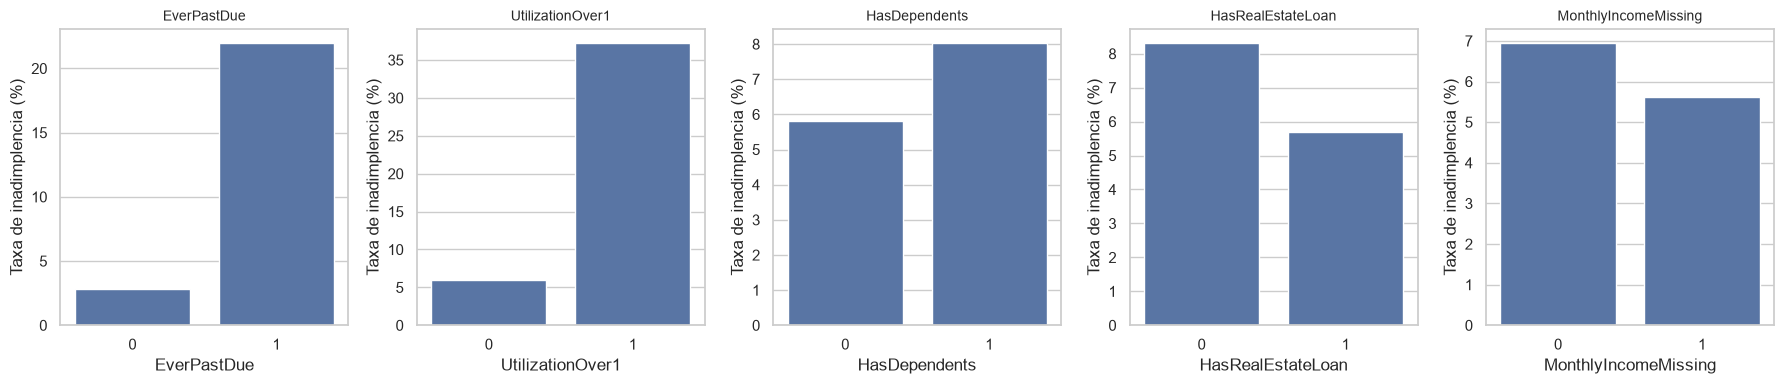

In [3]:
flags = ["EverPastDue", "UtilizationOver1", "HasDependents", "HasRealEstateLoan", "MonthlyIncomeMissing"]

fig, axes = plt.subplots(1, len(flags), figsize=(18, 4))
for ax, flag in zip(axes, flags):
    rate = df.groupby(flag)["SeriousDlqin2yrs"].mean() * 100
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax, color="#4C72B0")
    ax.set_title(flag, fontsize=10)
    ax.set_ylabel("Taxa de inadimplencia (%)")
plt.tight_layout()
plt.show()


**Nota:** `EverPastDue` (ja teve atraso registrado) deve mostrar a maior diferenca na taxa de inadimplencia — esperado, ja que atraso passado e o sinal mais forte de risco futuro em modelos de credito. Os demais flags tendem a ter efeito mais moderado, mas ainda uteis para o modelo.

## Distribuicao de TotalTimesPastDue

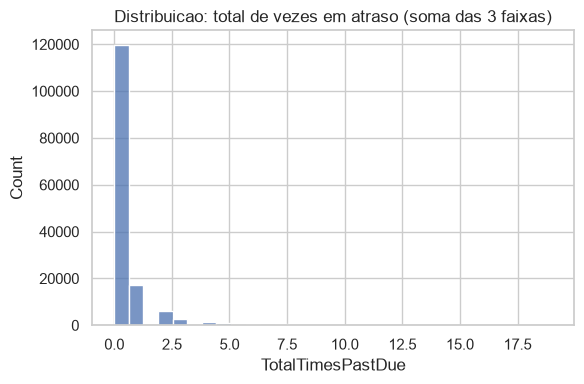

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df["TotalTimesPastDue"], bins=30, ax=ax, color="#4C72B0")
ax.set_title("Distribuicao: total de vezes em atraso (soma das 3 faixas)")
plt.tight_layout()
plt.show()


## Pipeline de pre-processamento (imputacao e outliers)

A celula abaixo apenas demonstra o pipeline definido em `src/features.py` — o `fit` real acontece em `03_modelagem.ipynb`, somente sobre `X_train`.

In [5]:
from src.features import build_preprocessing_pipeline

preprocessing = build_preprocessing_pipeline()
preprocessing


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute_income_dependents', ...), ('winsorize_outliers', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicativ

## Exportar dataset com atributos derivados

In [6]:
output_path = "../data/processed/credit_features.csv"
df.to_csv(output_path, index=False)
print(f"Salvo em {output_path} ({df.shape[0]} linhas, {df.shape[1]} colunas)")


Salvo em ../data/processed/credit_features.csv (149999 linhas, 18 colunas)


## Conclusoes

- Atributos derivados criados: `TotalTimesPastDue`, `EverPastDue`, `UtilizationOver1`, `HasDependents`, `HasRealEstateLoan`, flags de ausencia.
- Estrategia de imputacao (mediana) e winsorizacao (percentil 99) definida como `ColumnTransformer`, a ser ajustada somente em `X_train` — sem vazamento de dados.
- Dataset com atributos derivados exportado para `data/processed/credit_features.csv` (tambem sera a fonte do dashboard Power BI).
- Proximo passo: `03_modelagem.ipynb`.